# 2D Fractional PDE Solver via fPINN

This notebook trains a Physics-Informed Neural Network (PINN) to solve a 2D
time-fractional PDE using a Caputo-type fractional derivative discretized
through either the Diethelm scheme or the L1 scheme.

## Contents

1. **Configuration** — all hyperparameters and domain settings in one place.
2. **Imports & reproducibility** — library imports and random seed setup.
3. **Collocation points & boundary data** — grid construction.
4. **Fractional derivative operators** — Caputo, Riemann–Liouville, L1.
5. **Neural network model** — PINN architecture.
6. **PINN solver** — loss function, training loop, stopping criteria.
7. **Training** — instantiate the solver and run it.
8. **Results & export** — visualization and data export.
9. **Quantitative evaluation** — L2/L∞ errors, multi-run statistics, scan curves.

## Notes

- Full-batch training (no minibatching).
- Adam optimizer with piecewise constant learning rate schedule.
- Training stops on max iterations, wall-clock time limit, or convergence
  (relative loss change below tolerance over the last 100 iterations).

## 1. Configuration

All tunable parameters live here. Change these — not the cells below.

In [1]:
# ---- Domain ------------------------------------------------------------
XMIN, XMAX = 0.0, 2.0     # spatial domain
TMIN, TMAX = 0.0, 1.0     # temporal domain (time window)

# ---- Collocation grid --------------------------------------------------
NX, NT = 10, 10           # number of collocation points in x and t

# ---- Fractional derivative --------------------------------------------
ALPHA = 0.5               # fractional order (Caputo)
METHOD = 'caputo'         # 'caputo' (Diethelm) or 'L1'

# ---- Network architecture ---------------------------------------------
NUM_HIDDEN_LAYERS = 4
NUM_NEURONS_PER_LAYER = 20
ACTIVATION = 'tanh'
KERNEL_INITIALIZER = 'glorot_normal'

# ---- Optimizer --------------------------------------------------------
# Piecewise constant learning rate: lr=1e-2 for first 2000 steps,
# then 5e-3 until 5000 steps, then 1e-3 thereafter.
LR_BOUNDARIES = [2000, 5000]
LR_VALUES = [1e-2, 5e-3, 1e-3]

# ---- Training loop ----------------------------------------------------
MAX_ITERATIONS = int(3e5) + 1
TIME_STOP_HOURS = 0.05    # wall-clock time limit for a single training run
ES_WINDOW = 100           # rolling window size for relative loss stability
ES_TOL_PERCENT = 1e-1     # early stopping tolerance (percent)
CALLBACK_EVERY = 200      # print & save every N iterations

# ---- Reproducibility --------------------------------------------------
RANDOM_SEED = 42

# ---- Data type --------------------------------------------------------
DTYPE = 'float32'

## 2. Imports and Reproducibility

In [2]:
import os
import csv
from time import time

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Set default dtype for all TF operations
tf.keras.backend.set_floatx(DTYPE)

# Fix random seed for reproducibility
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Constants
PI = tf.constant(np.pi, dtype=DTYPE)


def gamma_tf(x):
    """Gamma function for TF tensors (via log-gamma)."""
    return tf.exp(tf.math.lgamma(x))

## 3. Collocation Points and Boundary Data

We build three sets of points:
- **Interior collocation** `X_r` — structured grid on $[x_{\min}, x_{\max}] \times [t_{\min}, t_{\max}]$ with `NX` × `NT` points.
- **Initial condition** `X_0` — points at $t = t_{\min}$.
- **Boundary conditions** `X_lb`, `X_rb` — points at $x = x_{\min}$ and $x = x_{\max}$.

In [3]:
# ---- Domain bounds ----------------------------------------------------
lb = [XMIN, TMIN]
ub = [XMAX, TMAX]

n_total = NX * NT

# ---- Initial condition points (t = TMIN) ------------------------------
t_0 = tf.ones((n_total, 1), dtype=DTYPE) * lb[1]
x_0 = tf.random.uniform((n_total, 1), lb[0], ub[0], dtype=DTYPE)
X_0 = tf.concat([x_0, t_0], axis=1)

# ---- Boundary points (x = XMIN and x = XMAX) --------------------------
t_b = tf.random.uniform((n_total, 1), lb[1], ub[1], dtype=DTYPE)
x_l = tf.ones((n_total, 1), dtype=DTYPE) * lb[0]
x_r = tf.ones((n_total, 1), dtype=DTYPE) * ub[0]
X_lb = tf.concat([x_l, t_b], axis=1)
X_rb = tf.concat([x_r, t_b], axis=1)

# ---- Interior collocation grid ----------------------------------------
x_r_f = tf.linspace(lb[0], ub[0], NX)
t_r_f = tf.linspace(lb[1], ub[1], NT)
T, X = tf.meshgrid(t_r_f, x_r_f)
X_r = tf.reshape(tf.stack([X, T], axis=2), [-1, 2])

# Grid spacing in time (used by fractional derivative operators)
h_t = (TMAX - TMIN) / (len(t_r_f) - 1)

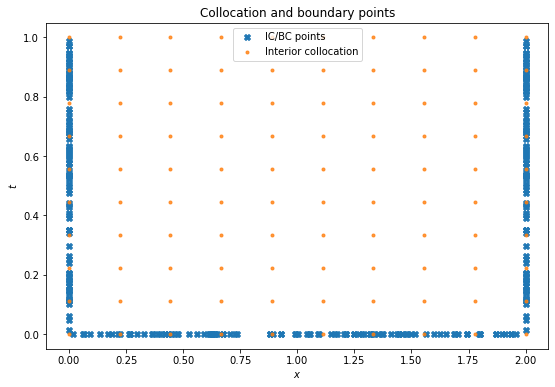

In [4]:
# Visualize collocation and boundary points
fig = plt.figure(figsize=(9, 6))
plt.scatter(x_0, t_0, c='tab:blue', marker='X', label='IC/BC points')
plt.scatter(x_l, t_b, c='tab:blue', marker='X')
plt.scatter(x_r, t_b, c='tab:blue', marker='X')
plt.scatter(X_r[:, 0], X_r[:, 1], c='tab:orange', marker='.', alpha=0.8,
            label='Interior collocation')
plt.xlabel('$x$')
plt.ylabel('$t$')
plt.legend()
plt.title('Collocation and boundary points')
plt.savefig('Collocation_Points.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Fractional Derivative Operators

Three discretization schemes are implemented:

- **Caputo (Diethelm)** — second-order accurate approximation of the Caputo derivative.
- **Riemann–Liouville (RL)** — used for fractional integrals.
- **L1 scheme** — first-order accurate approximation of the Caputo derivative.

Each operator consumes a sequence of function values on the time grid and returns
the fractional derivative at a single time index.

In [5]:
def caputo_derivative(order, f, data_point, h):
    """Diethelm-type discretization of the Caputo fractional derivative.

    Parameters
    ----------
    order : float
        Fractional order in (0, 1).
    f : tf.Tensor
        Function values on the time grid.
    data_point : int
        Time index at which to evaluate the derivative.
    h : float
        Time step.
    """
    summation = 0.0
    for k in range(data_point + 1):
        if k == 0:
            sigma = 1.0
        elif 0 < k < data_point:
            sigma = ((k - 1.0) ** (1 - order)
                     - 2.0 * k ** (1.0 - order)
                     + (k + 1.0) ** (1.0 - order))
        else:  # k == data_point
            sigma = ((k - 1.0) ** (1.0 - order)
                     - k ** (1.0 - order)
                     + (1.0 - order) * k ** (-order))
        summation += sigma * f[data_point - k]
    return h ** (-order) / gamma_tf(2.0 - order) * summation


def rl_derivative(order, f, data_point, h):
    """Riemann–Liouville fractional derivative/integral (sign of order matters)."""
    summation = 0.0
    for k in range(data_point + 1):
        if k == 0 and data_point != 0:
            sigma = ((1 + order) * data_point ** order
                     - data_point ** (1.0 + order)
                     + (data_point - 1.0) ** (1.0 + order))
        elif k == data_point:
            sigma = 1.0
        elif 0 < k < data_point:
            sigma = ((data_point - k + 1.0) ** (1.0 + order)
                     - 2.0 * (data_point - k) ** (1.0 + order)
                     + (data_point - k - 1.0) ** (1.0 + order))
        summation += sigma * f[k]
    return h ** order / gamma_tf(2.0 + order) * summation


def _bj(j, alpha):
    """Coefficient used in the L1 scheme."""
    return ((j + 1) ** (1.0 - alpha) - j ** (1.0 - alpha)) / gamma_tf(2.0 - alpha)


def l1_derivative(alpha, f, data_point, h):
    """L1-scheme approximation of the Caputo fractional derivative."""
    if data_point == 0:
        return 0.0  # initial condition
    n = data_point
    y = f
    total = _bj(0, alpha) * y[n] - _bj(n - 1, alpha) * y[0]
    for j in range(1, n):
        total += (_bj(j, alpha) - _bj(j - 1, alpha)) * y[n - j]
    return h ** (-alpha) * total

## 5. Neural Network Model

In [6]:
class PINN_NeuralNet(tf.keras.Model):
    """Fully-connected PINN architecture.

    Input: (x, t) pairs.
    Output: approximation of u(x, t).
    """

    def __init__(self, lb, ub,
                 output_dim=1,
                 num_hidden_layers=NUM_HIDDEN_LAYERS,
                 num_neurons_per_layer=NUM_NEURONS_PER_LAYER,
                 activation=ACTIVATION,
                 kernel_initializer=KERNEL_INITIALIZER,
                 **kwargs):
        super().__init__(**kwargs)

        self.num_hidden_layers = num_hidden_layers
        self.output_dim = output_dim
        self.lb = lb
        self.ub = ub

        self.hidden = [
            tf.keras.layers.Dense(
                num_neurons_per_layer,
                activation=tf.keras.activations.get(activation),
                kernel_initializer=kernel_initializer,
            )
            for _ in range(num_hidden_layers)
        ]
        self.out = tf.keras.layers.Dense(output_dim)

    def call(self, X):
        """Forward pass."""
        Z = X
        for layer in self.hidden:
            Z = layer(Z)
        return self.out(Z)

## 6. PINN Solver

The solver handles:
- **Residual assembly** via `get_r`, combining the fractional derivative, spatial derivatives, and the forcing term.
- **Loss function** as a sum of equation, initial-condition, and boundary-condition losses.
- **Training loop** `solve_with_TFoptimizer` with three stopping criteria.
- **Callback** for periodic logging and weight checkpointing.

In [7]:
class PINNSolver:
    """PINN solver for the 2D time-fractional PDE."""

    def __init__(self, model, X_r, csv_writer=None):
        self.model = model
        self.X_r = X_r
        self.csv_writer = csv_writer

        # Training state
        self.hist = []
        self.iter = 0
        self.last_n_losses = []
        self.loss_fracs = []
        self.current_loss = None
        self.max_relative_error = 100.0
        self.t0 = None

    # ------------------------------------------------------------------
    # Early stopping helpers
    # ------------------------------------------------------------------
    def update_last_n_losses(self, loss):
        """Maintain a rolling window of the last `ES_WINDOW` loss values."""
        self.last_n_losses.append(loss)
        if len(self.last_n_losses) > ES_WINDOW:
            self.last_n_losses.pop(0)

    def early_stopping_metric(self):
        """Maximum relative loss change over the last `ES_WINDOW` iterations.

        Used as an early-stopping signal: when this falls below ES_TOL_PERCENT,
        training is considered to have converged.
        """
        if len(self.last_n_losses) < ES_WINDOW:
            return 100.0  # sentinel
        current = self.last_n_losses[-1]
        return 100.0 * max(
            abs(current - loss) / current for loss in self.last_n_losses[:-1]
        )

    # ------------------------------------------------------------------
    # PDE residual
    # ------------------------------------------------------------------
    def get_r(self):
        """Assemble the PDE residual over the collocation grid."""
        x, t = tf.split(self.X_r, [1, 1], axis=1)

        # Second spatial derivative via nested GradientTapes
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(x)
            with tf.GradientTape(persistent=True) as tape:
                tape.watch(x)
                u = self.model(tf.concat([x, t], axis=1))
            u_x = tape.gradient(u, x)
        u_xx = tape2.gradient(u_x, x)
        del tape, tape2

        # Time-fractional derivative, row-by-row over x
        ud = tf.reshape(u, [NX, NT])
        ufd = tf.TensorArray(tf.float32, size=NX)
        for i in tf.range(NX):
            if METHOD == 'caputo':
                row = [caputo_derivative(ALPHA, ud[i, :], idx, h_t) for idx in range(NT)]
            else:
                row = [l1_derivative(ALPHA, ud[i, :], idx, h_t) for idx in range(NT)]
            ufd = ufd.write(i, row)
        ufd = tf.reshape(ufd.stack(), (-1, 1))

        uu = self.model(tf.concat([x, t], axis=1))

        # Forcing term (problem-specific)
        f_xt = (2.0 / gamma_tf(3.0 - ALPHA) * x * (2.0 - x) * t ** (2.0 - ALPHA)
                + t ** 2 * x * (2.0 - x)
                + 2 * t ** 2)

        res = ufd + uu - (u_xx + f_xt)

        # Component losses
        loss_eq = tf.reduce_mean(tf.square(res))
        loss_bc = (tf.reduce_mean(tf.square(self.model(X_lb) - 0.0))
                   + tf.reduce_mean(tf.square(self.model(X_rb) - 0.0)))
        loss_init = tf.reduce_mean(tf.square(self.model(X_0) - 0.0))

        phi_r = loss_eq + loss_bc + loss_init
        self.loss_fracs = [loss_eq, loss_init, loss_bc]
        return phi_r

    def loss_fn(self):
        loss_eq = self.get_r()
        return loss_eq, [loss_eq]

    def get_grad(self):
        with tf.GradientTape(persistent=True) as tape:
            tape.watch(self.model.trainable_variables)
            loss, loss_frac = self.loss_fn()
        g = tape.gradient(loss, self.model.trainable_variables)
        del tape
        return loss, g, loss_frac

    # ------------------------------------------------------------------
    # Training loop
    # ------------------------------------------------------------------
    def solve_with_TFoptimizer(self, optimizer, N=MAX_ITERATIONS):
        """Train the network.

        Three stopping criteria:
        1. Maximum iteration count `N` reached.
        2. Wall-clock time exceeds `TIME_STOP_HOURS`.
        3. Relative loss change in the last `ES_WINDOW` iterations falls below
           `ES_TOL_PERCENT`.
        """
        @tf.function
        def train_step():
            loss, grad_theta, loss_frac = self.get_grad()
            optimizer.apply_gradients(zip(grad_theta, self.model.trainable_variables))
            return loss, loss_frac

        time_limit_secs = TIME_STOP_HOURS * 3600
        self.t0 = time()
        i = 0

        while i < N and (time() - self.t0) < time_limit_secs:
            loss, loss_frac = train_step()
            self.loss_frac = loss_frac
            self.current_loss = loss.numpy()
            self.max_relative_error = self.early_stopping_metric()
            self.callback()
            self.update_last_n_losses(self.current_loss)
            i += 1

            # Convergence-based early stopping
            if self.max_relative_error < ES_TOL_PERCENT:
                tf.print('Early stopping... It {:05,d}: Loss = {:10.4e}, '
                         'Max rel error = {}%'.format(
                             self.iter, self.current_loss,
                             np.round(self.max_relative_error, 3)))
                self._save_weights()
                break

    # ------------------------------------------------------------------
    # Callback: logging + checkpointing
    # ------------------------------------------------------------------
    def callback(self):
        if self.iter % CALLBACK_EVERY == 0:
            print('It {:05d}: loss = {:10.8e}'.format(self.iter, self.current_loss))
            self._save_weights()
            if self.t0 is not None:
                print('time', time() - self.t0)

            if self.csv_writer is not None:
                row = [
                    self.iter,
                    tf.get_static_value(self.loss_fracs[0]),
                    tf.get_static_value(self.loss_fracs[1]),
                    tf.get_static_value(self.loss_fracs[2]),
                    self.current_loss,
                ]
                self.csv_writer.writerow(row)

        self.hist.append(self.current_loss)
        self.iter += 1

    def _save_weights(self):
        tag = 'cpt' if METHOD == 'caputo' else 'L1'
        path = f'WEIGHTS_{NT}t{NX}x_tmax{TMAX}_{tag}/my_model.tf'
        self.model.save_weights(path, overwrite=True)

    def plot_loss_history(self, ax=None):
        if ax is None:
            fig = plt.figure(figsize=(7, 5))
            ax = fig.add_subplot(111)
        ax.semilogy(range(len(self.hist)), self.hist, 'k-')
        ax.set_xlabel(r'$n_{epoch}$')
        ax.set_ylabel(r'$\phi^{n_{epoch}}$')
        return ax

## 7. Training

In [8]:
# ---- Open CSV log -----------------------------------------------------
csv_filename = (f'Loss_History{NT}t{NX}x_tmax{TMAX}_{METHOD}'
                f'_runtime{TIME_STOP_HOURS}hours.csv')
csv_file = open(csv_filename, mode='w', newline='')
csv_writer = csv.writer(csv_file, delimiter=',', quotechar='"', quoting=csv.QUOTE_MINIMAL)
csv_writer.writerow(["EPOCH #", "EQ Loss", "IC Loss", "BC Loss", "Total Loss"])

# ---- Instantiate model and solver -------------------------------------
model = PINN_NeuralNet(lb, ub)
model.build(input_shape=(None, 2))
solver = PINNSolver(model, X_r, csv_writer=csv_writer)

# ---- Build optimizer with piecewise constant learning rate ------------
lr = tf.keras.optimizers.schedules.PiecewiseConstantDecay(
    LR_BOUNDARIES, LR_VALUES
)
optim = tf.keras.optimizers.legacy.Adam(learning_rate=lr)

In [9]:
# ---- Run training -----------------------------------------------------
try:
    t_start = time()
    solver.solve_with_TFoptimizer(optim, N=MAX_ITERATIONS)
    runtime_minutes = (time() - t_start) / 60
    print(f'\nRuntime: {runtime_minutes:.3f} minutes')
except KeyboardInterrupt:
    runtime_minutes = (time() - t_start) / 60
    print(f'\nInterrupted. Runtime: {runtime_minutes:.3f} minutes')
finally:
    csv_file.close()

2026-04-21 12:42:58.505617: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


It 00000: loss = 2.33297849e+00
time 4.606934070587158
It 00200: loss = 7.12493658e-02
time 6.0144782066345215
It 00400: loss = 3.72080505e-02
time 7.418788194656372
It 00600: loss = 9.94016998e-04
time 8.785667896270752
It 00800: loss = 5.74860431e-04
time 10.204439163208008
It 01000: loss = 5.61394787e-04
time 11.57077407836914

Interrupted. Runtime: 0.215 minutes


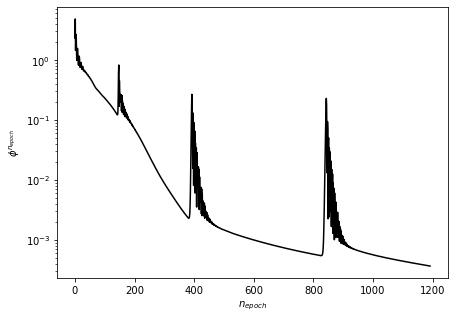

In [10]:
# Plot loss history
solver.plot_loss_history()
filename = f'{METHOD}_loss_history_{NT}pts_tmax{TMAX}s_runtime{TIME_STOP_HOURS}hours.png'
plt.savefig(filename, dpi=300, transparent=False, bbox_inches='tight')
plt.show()

## 8. Results and Export

In [11]:
def exact_solution(X_r):
    """Analytical reference solution for the benchmark problem."""
    x, t = X_r[:, 0], X_r[:, 1]
    return t ** 2 * x * (2.0 - x)


# Evaluation grid
NUM_PLOT_POINTS = 60
x_eval = np.linspace(XMIN, XMAX, NUM_PLOT_POINTS)
t_eval = np.linspace(TMIN, TMAX, NUM_PLOT_POINTS)
X_grid, T_grid = np.meshgrid(x_eval, t_eval)
X_flat = np.stack([X_grid.flatten(), T_grid.flatten()], axis=1)

u_pred = model(X_flat).numpy().reshape((NUM_PLOT_POINTS, NUM_PLOT_POINTS))
u_ref = exact_solution(X_flat).reshape((NUM_PLOT_POINTS, NUM_PLOT_POINTS))

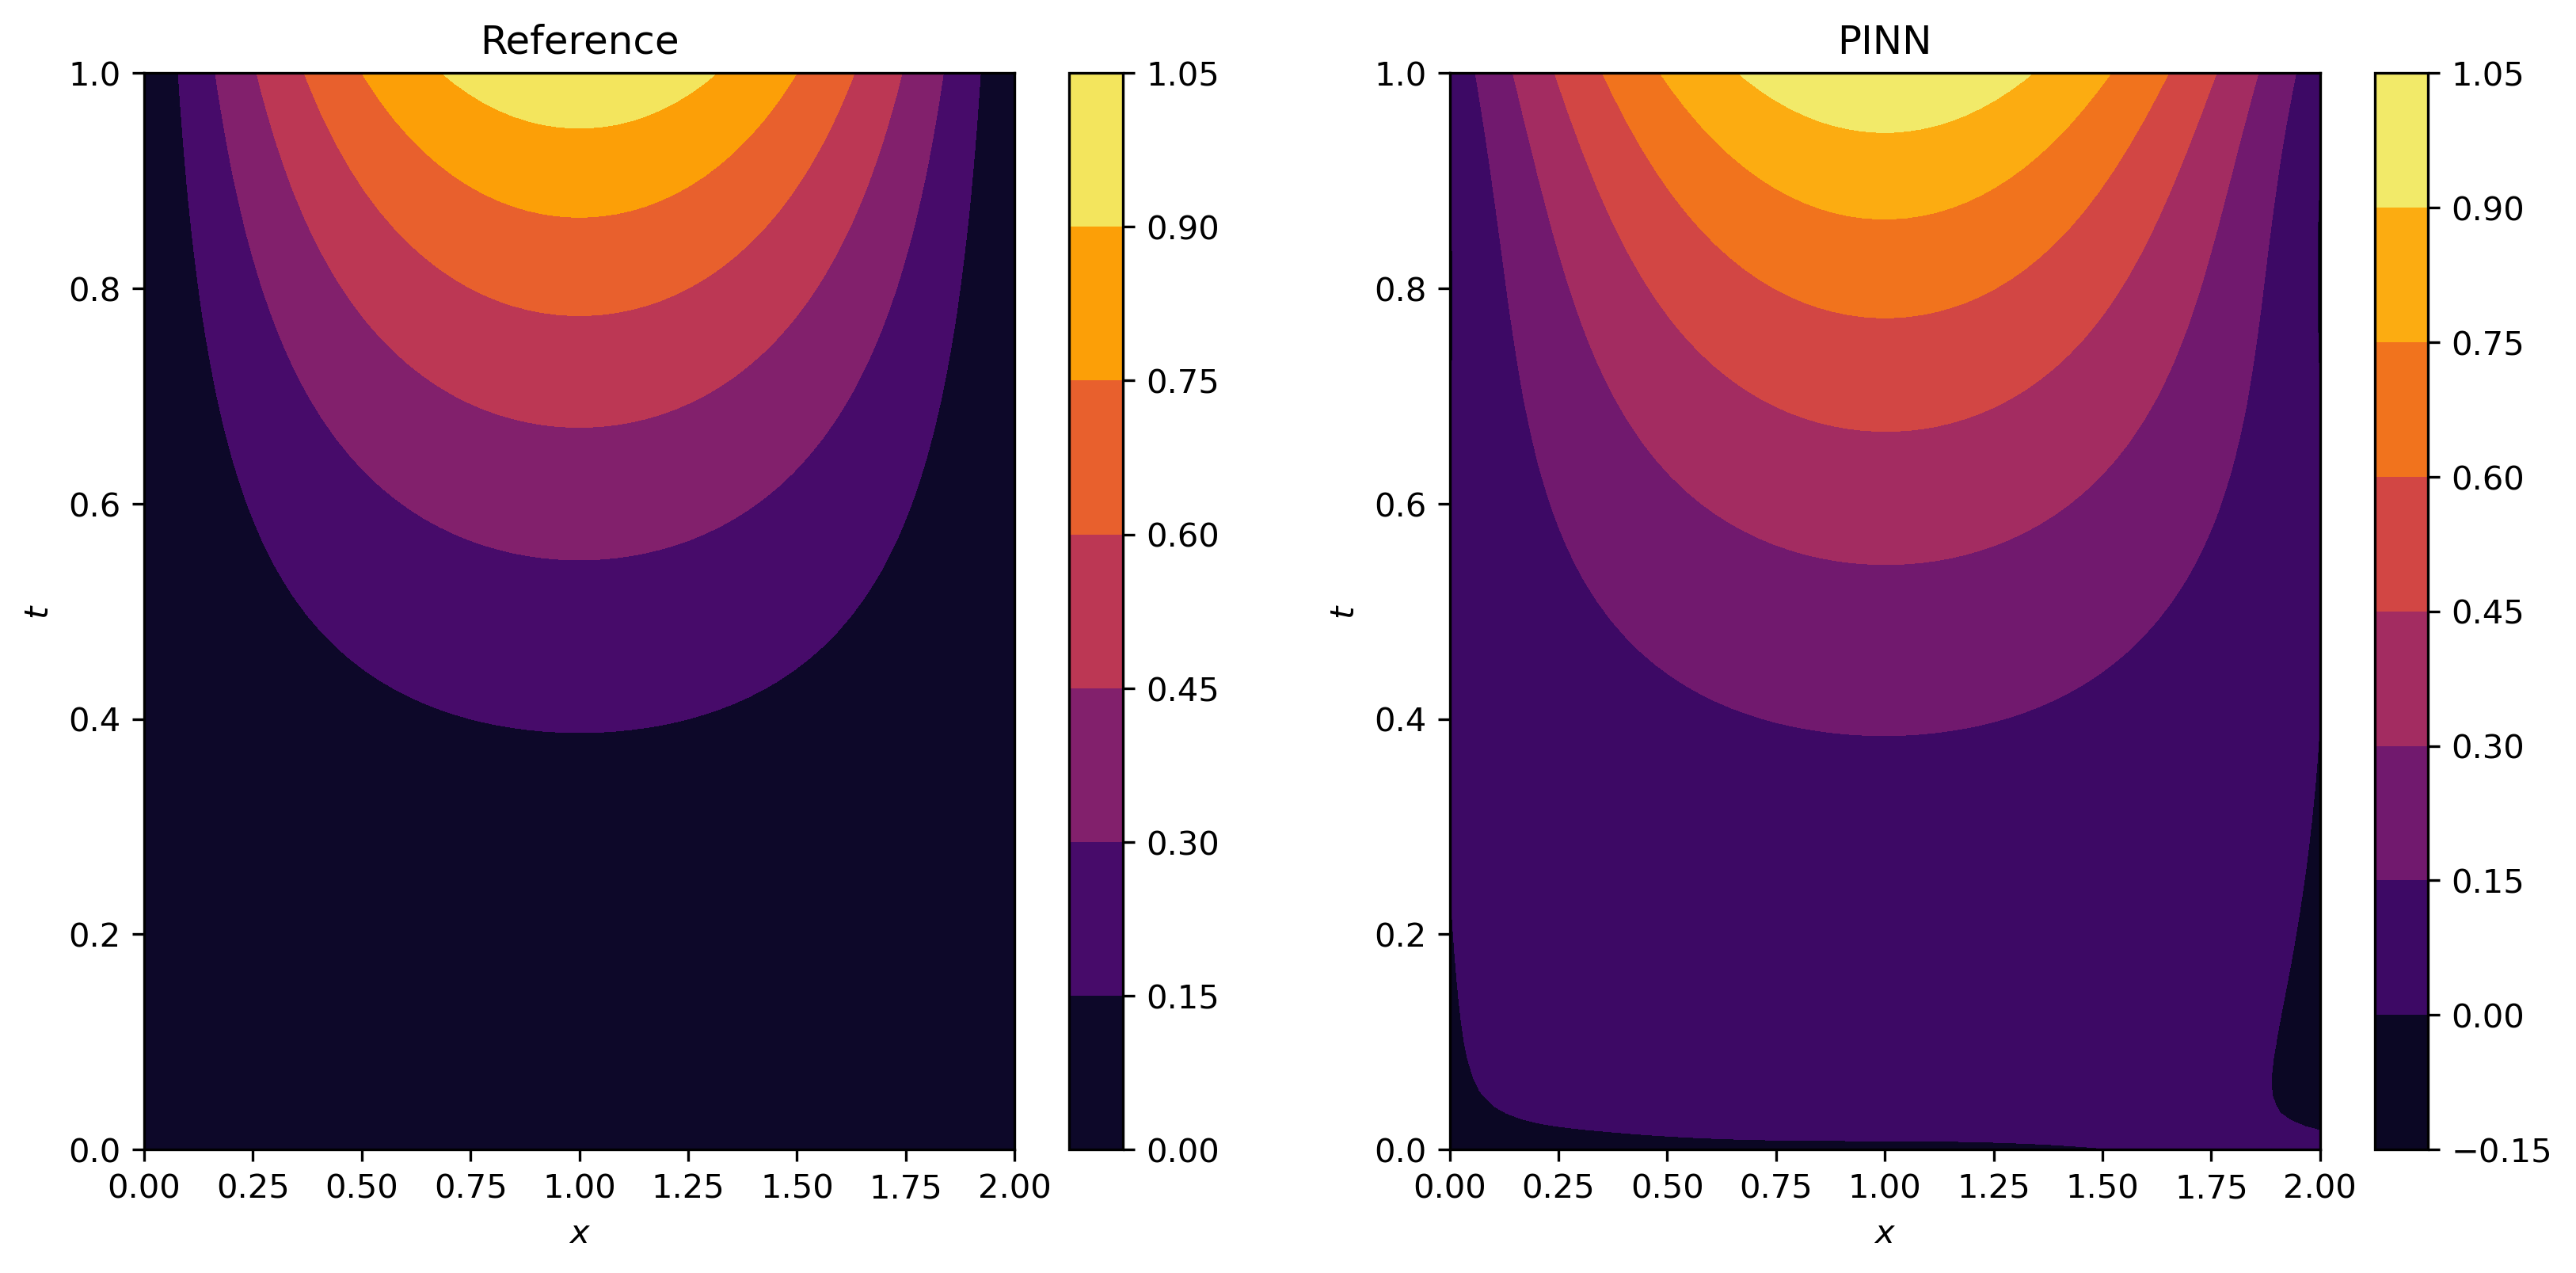

In [12]:
# Side-by-side contour plot: reference vs PINN prediction
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(13, 6), dpi=300)
gs = GridSpec(1, 2, width_ratios=[1, 1], wspace=0.2)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

cp1 = ax1.contourf(X_grid, T_grid, u_ref, cmap='inferno')
fig.colorbar(cp1, ax=ax1)
ax1.set_title('Reference')
ax1.set_xlabel('$x$')
ax1.set_ylabel('$t$')

cp2 = ax2.contourf(X_grid, T_grid, u_pred, cmap='inferno')
fig.colorbar(cp2, ax=ax2)
ax2.set_title('PINN')
ax2.set_xlabel('$x$')
ax2.set_ylabel('$t$')

filename = f'contours_of_NN_with_{NT}_points_in_time_and_tmax_{TMAX}s.png'
plt.savefig(filename, dpi=300, transparent=False, bbox_inches='tight')
plt.show()

In [13]:
# Export predictions and reference values to a single spreadsheet
import pandas as pd
from datetime import datetime

os.makedirs('Exports', exist_ok=True)
df = pd.DataFrame({
    'X': X_grid.flatten(),
    'T': T_grid.flatten(),
    'u_predictions': u_pred.flatten(),
    'u_exact': u_ref.flatten(),
})
export_path = f"Exports/V_4_{datetime.now().strftime('%Y_%m_%d-%H_%M_%S')}.xlsx"
df.to_excel(export_path, index=False)
print(f'Data exported to {export_path}')

Data exported to Exports/V_4_2026_04_21-12_43_25.xlsx


## 9. Training Variability (Multi-Seed Runs)

Reviewer 1 Q2 asks for mean ± std over several runs to demonstrate training
variability. We rerun **one representative configuration** (N = 50, tmax = 0.5,
Caputo/Diethelm) three times with different random seeds and report summary
statistics.

The error-vs-N and error-vs-runtime curves are produced in the plotter
(Section 9 of `2DfPDE_plotter.ipynb`) directly from saved weights — no
re-training needed for those.

### 9.1 Error metrics helper

In [14]:
def compute_error_metrics(model, num_points=60):
    """L2 relative error and L-infinity absolute error against the exact solution."""
    x_eval = np.linspace(XMIN, XMAX, num_points)
    t_eval = np.linspace(TMIN, TMAX, num_points)
    X_grid, T_grid = np.meshgrid(x_eval, t_eval)
    X_flat = np.stack([X_grid.flatten(), T_grid.flatten()], axis=1)

    u_pred = model(X_flat).numpy().flatten()
    u_ref = exact_solution(X_flat)

    l2_rel = np.linalg.norm(u_pred - u_ref) / np.linalg.norm(u_ref)
    linf_abs = np.max(np.abs(u_pred - u_ref))
    return float(l2_rel), float(linf_abs)


# Quick baseline: metrics for the model trained in Section 7
l2, linf = compute_error_metrics(model)
print(f'Baseline (seed={RANDOM_SEED}): L2 rel = {l2:.4e}, '
      f'Linf abs = {linf:.4e}, runtime = {runtime_minutes:.3f} min')

Baseline (seed=42): L2 rel = 1.6331e-02, Linf abs = 4.7026e-02, runtime = 0.215 min


### 9.2 Multi-seed experiment

Rerun the same configuration three times with different random seeds and
aggregate the metrics.

In [15]:
def train_single_run(seed, time_stop_hours=TIME_STOP_HOURS,
                     max_iters=MAX_ITERATIONS, verbose=False):
    """Train one model with a given seed; return its final metrics.

    This rebuilds the collocation grid using the current globals (NX, NT,
    TMAX, METHOD) and temporarily overrides the wall-clock limit via
    `time_stop_hours`. It does NOT mutate the main `model`/`solver` objects.
    """
    tf.random.set_seed(seed)
    np.random.seed(seed)

    # Fresh collocation grid for this run (so IC/BC random points are reseeded)
    lb_r = [XMIN, TMIN]
    ub_r = [XMAX, TMAX]
    n_total = NX * NT
    t0_r = tf.ones((n_total, 1), dtype=DTYPE) * lb_r[1]
    x0_r = tf.random.uniform((n_total, 1), lb_r[0], ub_r[0], dtype=DTYPE)
    X0_r = tf.concat([x0_r, t0_r], axis=1)
    tb_r = tf.random.uniform((n_total, 1), lb_r[1], ub_r[1], dtype=DTYPE)
    xl_r = tf.ones((n_total, 1), dtype=DTYPE) * lb_r[0]
    xr_r = tf.ones((n_total, 1), dtype=DTYPE) * ub_r[0]
    Xlb_r = tf.concat([xl_r, tb_r], axis=1)
    Xrb_r = tf.concat([xr_r, tb_r], axis=1)
    xs = tf.linspace(lb_r[0], ub_r[0], NX)
    ts = tf.linspace(lb_r[1], ub_r[1], NT)
    Tg, Xg = tf.meshgrid(ts, xs)
    Xr_r = tf.reshape(tf.stack([Xg, Tg], axis=2), [-1, 2])

    # PINNSolver reads X_0, X_lb, X_rb as globals; swap them in temporarily.
    global X_0, X_lb, X_rb, TIME_STOP_HOURS
    saved = (X_0, X_lb, X_rb, TIME_STOP_HOURS)
    X_0, X_lb, X_rb = X0_r, Xlb_r, Xrb_r
    TIME_STOP_HOURS = time_stop_hours

    try:
        m = PINN_NeuralNet(lb_r, ub_r)
        m.build(input_shape=(None, 2))
        s = PINNSolver(m, Xr_r, csv_writer=None)
        lr_s = tf.keras.optimizers.schedules.PiecewiseConstantDecay(
            LR_BOUNDARIES, LR_VALUES)
        opt_s = tf.keras.optimizers.legacy.Adam(learning_rate=lr_s)

        t_start = time()
        s.solve_with_TFoptimizer(opt_s, N=max_iters)
        runtime_min = (time() - t_start) / 60.0

        l2_r, linf_r = compute_error_metrics(m)
        final_loss = float(s.current_loss) if s.current_loss is not None else float('nan')

        if verbose:
            print(f'  seed={seed}: L2={l2_r:.3e}, Linf={linf_r:.3e}, '
                  f'loss={final_loss:.3e}, runtime={runtime_min:.2f} min')

        return {
            'seed': seed,
            'l2_rel': l2_r,
            'linf_abs': linf_r,
            'final_loss': final_loss,
            'runtime_minutes': runtime_min,
            'iterations': s.iter,
        }
    finally:
        X_0, X_lb, X_rb, TIME_STOP_HOURS = saved

In [16]:
# ---- Multi-seed experiment --------------------------------------------
# Representative configuration: the values currently set in Section 1.
# Use a short `time_stop_hours` for a sanity check; increase for the paper.
SEEDS = (42, 123, 2024, 7, 1337)

multi_run_results = []
for s in SEEDS:
    print(f'--- Run with seed {s} ---')
    multi_run_results.append(train_single_run(s, time_stop_hours=10/60,
                                              verbose=True))

# ---- Aggregate --------------------------------------------------------
def agg(results, key):
    vals = np.array([r[key] for r in results])
    return vals.mean(), vals.std()

print(f'\n===== Summary (mean ± std over {len(SEEDS)} runs) =====')
for key, label in [
    ('l2_rel', 'L2 relative error'),
    ('linf_abs', 'L-inf absolute error'),
    ('final_loss', 'Final loss'),
    ('runtime_minutes', 'Runtime (min)'),
]:
    m, sd = agg(multi_run_results, key)
    print(f'  {label:22s}: {m:.4e} ± {sd:.4e}')

--- Run with seed 42 ---
It 00000: loss = 2.33297849e+00
time 4.184350967407227
It 00200: loss = 7.12493658e-02
time 5.59645676612854
It 00400: loss = 3.72080505e-02
time 7.023093938827515
It 00600: loss = 9.94016998e-04
time 8.386148691177368
It 00800: loss = 5.74860431e-04
time 9.756903886795044
It 01000: loss = 5.61394787e-04
time 11.137540102005005
It 01200: loss = 3.58864520e-04
time 12.505232810974121
It 01400: loss = 1.50527447e-01
time 13.8713960647583
It 01600: loss = 2.65188486e-04
time 15.237636804580688
It 01800: loss = 1.78476606e-04
time 16.603214025497437
It 02000: loss = 2.79561238e-04
time 18.007457971572876
It 02200: loss = 1.96631227e-04
time 19.397246837615967
It 02400: loss = 1.55887232e-04
time 20.758220911026
It 02600: loss = 1.26837709e-04
time 22.11704969406128
It 02800: loss = 1.03899729e-04
time 23.483802795410156
It 03000: loss = 8.53453894e-05
time 24.845427989959717
It 03200: loss = 7.04534759e-05
time 26.207895040512085
It 03400: loss = 5.87609611e-05
tim

In [17]:
# Export multi-run results for the paper
import pandas as pd

multi_df = pd.DataFrame(multi_run_results)
multi_df.to_csv(f'multiseed_{NT}t{NX}x_tmax{TMAX}_{METHOD}.csv', index=False)
print(multi_df.to_string(index=False))

 seed   l2_rel  linf_abs   final_loss  runtime_minutes  iterations
   42 0.007355  0.004532 8.214516e-07        10.000888       89104
  123 0.007899  0.004381 1.436337e-06        10.001048       89081
 2024 0.007501  0.005262 9.603342e-06        10.000936       91354
    7 0.006181  0.003897 1.027853e-05        10.001039       89775
 1337 0.003764  0.003786 1.095111e-04        10.001051       87650
